In [94]:
import pandas as pd
import os
from io import StringIO
from pandas import json_normalize
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import hmean

In [95]:
dataset = "Cora"
folder = os.path.join("output","runs","LinkAttack", "edge")

files = [f for f in os.listdir(folder) if dataset in f and ('20' in f)]
files

['Cora_SGCCGU_20.json',
 'Cora_GraphSAGE_20.json',
 'Cora_GAT_20.json',
 'Cora_GCN_20.json',
 'Cora_SGC_20.json']

In [96]:
column_list = ['unlearner', 'dataset', 'architecture', 'optimizer.parameters.lr','lr',
       'RunTime', 'PeakRSS_MB', 'CudaPeak_MB', 'AUS', 'UMIA',
       'sklearn.metrics.accuracy_score.test.unlearned.on_graph:True', 'sklearn.metrics.accuracy_score.forget.unlearned.on_graph:True',
       'sklearn.metrics.accuracy_score.train.unlearned.on_graph:True',
       'sklearn.metrics.accuracy_score.test.unlearned.on_graph:False',
       'sklearn.metrics.accuracy_score.test.original.on_graph:False',
       'f1_macro.test.unlearned.on_graph:True',
       'f1_macro.test.original.on_graph:True',
       'f1_macro.forget.unlearned.on_graph:True',
       'f1_macro.forget.original.on_graph:True',
       'Link Stealing Attack unlearned 0 exist/non_exist',
       'Link Stealing Attack 0 unlearned forget/non_exist', 'LinkTeller unlearn with sampler bfs+:',
       'LinkTeller original with sampler bfs+:']


In [97]:
total_df = pd.DataFrame()

for file in files:
    architecture = file.split("_")[1]
    if architecture == "SGC" and "CGU" in file:
        architecture = "SGC_CGU"
        
    file = os.path.join(folder,file)
    with open(file, "r") as f:
        text = f.read().strip()

    if not text.startswith("["):
        text = "[" + text
    if text.endswith(","):
        text = text[:-1]
    if not text.endswith("]"):
        text = text + "]"

    df = pd.read_json(StringIO(text))

    df_expanded = json_normalize(df['parameters'])
    df = pd.concat([df.drop(columns='parameters'), df_expanded], axis=1)

    df['architecture'] = architecture

    cols = list(df.columns)

    #cols.insert(2, cols.pop(cols.index('optimizer.parameters.lr')))

    cols.insert(2, cols.pop(cols.index('architecture')))

    df = df[cols]
    
    total_df = pd.concat([total_df,df])

In [98]:
total_df = total_df[column_list]

In [99]:
[f for f in total_df.columns.to_list() if 'eller' in f]

['LinkTeller unlearn with sampler bfs+:',
 'LinkTeller original with sampler bfs+:']

In [100]:
def harmonic_mean(row, metrics):
    values = row[metrics].values
    values = values[values > 0]
    if len(values) == 0:
        return np.nan
    return len(values) / np.sum(1.0 / values)

In [101]:
total_df = total_df[column_list]
total_df.reset_index(drop=True, inplace=True)

In [102]:
metric_cols = [c for c in column_list if c not in ["unlearner","dataset","architecture","lr","RunTime", 'optimizer.parameters.lr',  'Link Stealing Attack unlearned 0 exist/non_exist',
 'Link Stealing Attack 0 unlearned forget/non_exist',
 'LinkTeller_unlearn_auc',
 'LinkTeller_unlearn_ap',
 'LinkTeller_original_auc',
 'LinkTeller_original_ap']]

In [103]:
metric_cols

['PeakRSS_MB',
 'CudaPeak_MB',
 'AUS',
 'UMIA',
 'sklearn.metrics.accuracy_score.test.unlearned.on_graph:True',
 'sklearn.metrics.accuracy_score.forget.unlearned.on_graph:True',
 'sklearn.metrics.accuracy_score.train.unlearned.on_graph:True',
 'sklearn.metrics.accuracy_score.test.unlearned.on_graph:False',
 'sklearn.metrics.accuracy_score.test.original.on_graph:False',
 'f1_macro.test.unlearned.on_graph:True',
 'f1_macro.test.original.on_graph:True',
 'f1_macro.forget.unlearned.on_graph:True',
 'f1_macro.forget.original.on_graph:True',
 'LinkTeller unlearn with sampler bfs+:',
 'LinkTeller original with sampler bfs+:']

In [104]:
total_df[metric_cols] = total_df[metric_cols].clip(lower=0)

In [105]:
total_df["harmonic_mean"] = total_df[metric_cols].apply(
    lambda row: hmean(row.dropna()) if row.dropna().size > 0 else np.nan,
    axis=1
)

In [106]:
total_df

,unlearner,dataset,architecture,optimizer.parameters.lr,lr,RunTime,PeakRSS_MB,CudaPeak_MB,AUS,UMIA,...,sklearn.metrics.accuracy_score.test.original.on_graph:False,f1_macro.test.unlearned.on_graph:True,f1_macro.test.original.on_graph:True,f1_macro.forget.unlearned.on_graph:True,f1_macro.forget.original.on_graph:True,Link Stealing Attack unlearned 0 exist/non_exist,Link Stealing Attack 0 unlearned forget/non_exist,LinkTeller unlearn with sampler bfs+:,LinkTeller original with sampler bfs+:,harmonic_mean
0,Identity,Cora,SGCCGU,NaN,NaN,0.000437,1639.792969,228.428223,0.999968,0.502045,...,0.754613,0.673224,0.673224,0.605654,0.605654,0.691075,0.689582,NaN,NaN,0.807514
1,GoldModelGraph,Cora,SGCCGU,NaN,NaN,0.554871,1713.703125,448.163574,0.795909,0.808793,...,0.754613,0.448785,0.673224,0.422223,0.605654,0.574877,0.571352,NaN,NaN,0.695081
2,Finetuning,Cora,SGCCGU,0.001,NaN,0.131006,1760.132812,463.422363,1.001095,0.498978,...,0.754613,0.675470,0.673224,0.607010,0.605654,0.694296,0.692834,NaN,NaN,0.808174
3,SuccessiveRandomLabels,Cora,SGCCGU,0.001,NaN,20.051339,1776.011719,463.656738,1.002544,0.508180,...,0.754613,0.687684,0.673224,0.613664,0.605654,0.689338,0.687241,NaN,NaN,0.813639
4,Finetuning,Cora,SGCCGU,0.001,NaN,0.098399,1776.015625,463.500000,1.001095,0.507157,...,0.754613,0.675470,0.673224,0.607010,0.605654,0.694296,0.692834,NaN,NaN,0.809802
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,SelectiveSynapticDampening,Cora,SGC,0.001,0.1,20.253533,1980.332031,464.563965,0.974737,0.500000,...,0.756458,0.649467,0.644298,0.676502,0.649033,0.844158,0.854986,NaN,NaN,0.822530
81,Cascade,Cora,SGC,NaN,NaN,25.523301,2042.984375,464.486328,0.958430,0.505112,...,0.756458,0.646233,0.644298,0.656874,0.649033,0.842572,0.852290,NaN,NaN,0.815521
82,IDEA,Cora,SGC,NaN,NaN,1.222461,2118.792969,487.090332,0.996971,0.867076,...,0.756458,0.666407,0.644298,0.695125,0.649033,0.843902,0.856073,NaN,NaN,0.880511
83,CGU_edge,Cora,SGC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.756458,NaN,0.644298,NaN,0.649033,NaN,NaN,NaN,NaN,0.679535


In [107]:
total_df['architecture'].unique()

array(['SGCCGU', 'GraphSAGE', 'GAT', 'GCN', 'SGC'], dtype=object)

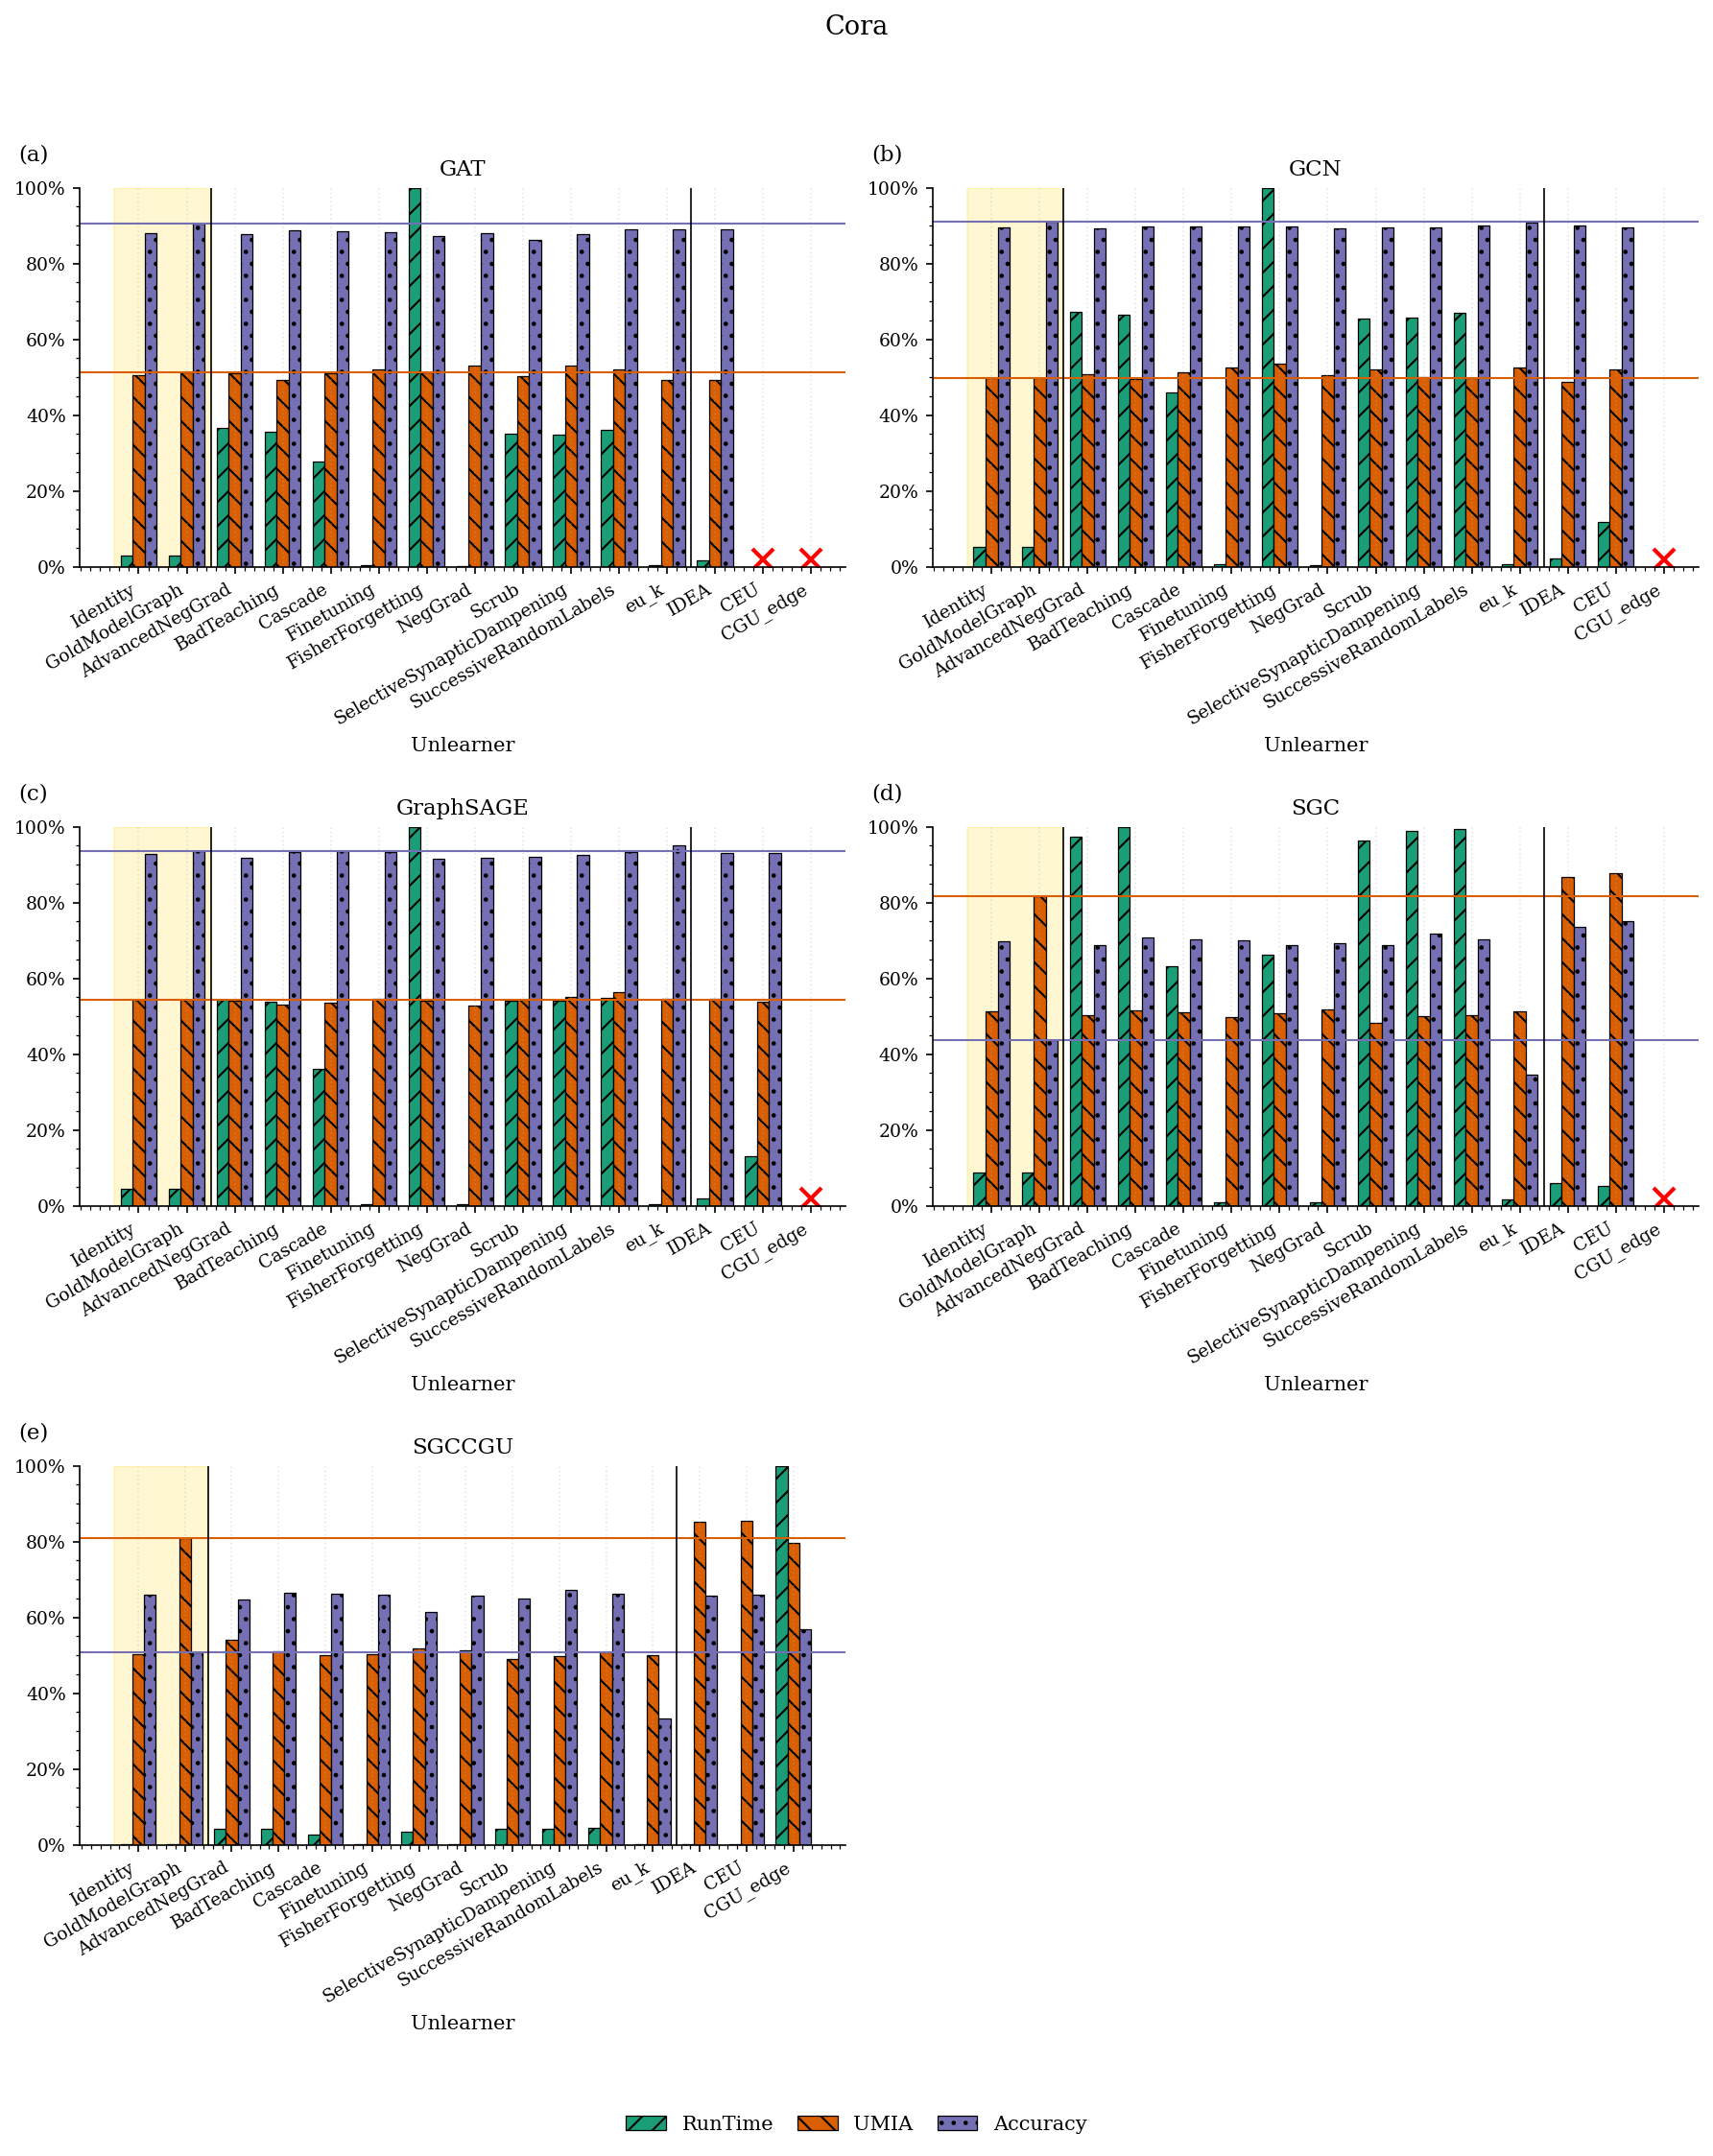

In [108]:
# --- Style polish: researchy vibe, no functional changes ---
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from string import ascii_lowercase

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "figure.dpi": 150,
    "savefig.dpi": 300,
})

ACC_COL = "sklearn.metrics.accuracy_score.forget.unlearned.on_graph:True"
METRICS = ["RunTime", "UMIA", ACC_COL]
DISPLAY_NAME = {
    "RunTime": "RunTime",
    "UMIA": "UMIA",
    ACC_COL: "Accuracy",
}

COLOR = {
    "RunTime": "#1b9e77",   # deep green-teal
    "UMIA":    "#d95f02",   # muted orange
    ACC_COL:   "#7570b3",   # indigo/purple
}
# b/w & color-blind friendly hatches per metric
HATCH = {
    "RunTime": "//",
    "UMIA":    "\\\\",
    ACC_COL:   "..",
}

HEAD = ["Identity", "GoldModelGraph"]        # shaded in gold
TAIL = ["IDEA", "CEU", "CGU_edge"]           # moved to the end

architectures = sorted(total_df["architecture"].unique())
n_arch = len(architectures)

# choose grid size (e.g. square-ish)
ncols = 2  # or 3 if you have many
nrows = math.ceil(n_arch / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows), squeeze=False)

for idx, arch in enumerate(architectures):
    ax = axes[idx // ncols, idx % ncols]  # pick correct subplot

    sub = total_df[total_df["architecture"] == arch].copy()
    agg = sub.groupby("unlearner")[METRICS].mean()

    # scale Identity / GoldModel runtime (as in your code)
    if "Finetuning" in agg.index:
        base = agg.loc["Finetuning", "RunTime"]
        if base > 0:
            for special in ["Identity", "GoldModelGraph"]:
                if special in agg.index:
                    agg.loc[special, "RunTime"] = base * 10

    # normalize runtime (as in your code)
    if agg["RunTime"].notna().any():
        max_rt = agg["RunTime"].max()
        if max_rt > 0:
            agg["RunTime"] /= max_rt

    # ordering (unchanged)
    present = list(agg.index)
    head_present = [u for u in HEAD if u in present]
    tail_present = [u for u in TAIL if u in present]
    middle = sorted([u for u in present if u not in head_present + tail_present])
    ordered_unlearners = head_present + middle + tail_present
    agg = agg.reindex(ordered_unlearners)

    x = np.arange(len(ordered_unlearners))
    width = 0.25
    offsets = np.linspace(-width, width, len(METRICS))

    # axes cosmetics
    ax.set_title(arch)
    ax.set_xlabel("Unlearner")
    if idx // ncols == 0:
        ax.set_ylim(0, 1)  # all three metrics are in [0,1] after your normalization
    else:
        ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    ax.minorticks_on()
    ax.grid(axis="x", linestyle=":", alpha=0.3)   # vertical only, subtle
    ax.tick_params(axis="x", rotation=30)

    # gold shading for HEAD
    if head_present:
        ax.axvspan(-0.5, len(head_present) - 0.5, color="#FFD700", alpha=0.18, zorder=0)

    # UMIA validity mask (unchanged)
    umia = agg["UMIA"].values if "UMIA" in agg.columns else np.full(len(x), np.nan)
    valid_mask = ~(np.isnan(umia) | (umia == 0))

    # red X for invalid groups (same logic, styled)
    if (~valid_mask).any():
        ymin, ymax = ax.get_ylim()
        offset = 0.02 * (ymax - ymin) if ymax > ymin else 0.02
        ax.plot(
            x[~valid_mask],
            np.full((~valid_mask).sum(), offset),
            marker="x", linestyle="None", color="red",
            markersize=11, markeredgewidth=2
        )

    # bars for valid groups (same functionality, with edge + hatch)
    for i, metric in enumerate(METRICS):
        vals = agg[metric].values
        ax.bar(
            x[valid_mask] + offsets[i],
            vals[valid_mask],
            width,
            label=DISPLAY_NAME[metric],
            color=COLOR[metric],
            edgecolor="black",
            linewidth=0.6,
            hatch=HATCH[metric],
        )

    ax.set_xticks(x)
    ax.set_xticklabels(ordered_unlearners, ha="right", fontsize=9)

    # reference lines from GoldModel (unchanged, slightly thinner)
    if "GoldModelGraph" in agg.index:
        gold = agg.loc["GoldModelGraph"]
        if np.isfinite(gold["UMIA"]):
            ax.axhline(y=gold["UMIA"], color=COLOR["UMIA"], linestyle="-", linewidth=1.0)
        if np.isfinite(gold[ACC_COL]):
            ax.axhline(y=gold[ACC_COL], color=COLOR[ACC_COL], linestyle="-", linewidth=1.0)

    # vertical separators (unchanged)
    if head_present and len(head_present) < len(ordered_unlearners):
        ax.axvline(x=len(head_present)-0.5, color="black", linestyle="-", linewidth=0.8)
    if tail_present:
        idx_before_tail = len(head_present) + len(middle) - 0.5
        if -0.5 <= idx_before_tail < len(ordered_unlearners)-0.5:
            ax.axvline(x=idx_before_tail, color="black", linestyle="-", linewidth=0.8)

    # panel label (a), (b), ...
    ax.text(-0.08, 1.06, f"({ascii_lowercase[idx]})", transform=ax.transAxes,
            va="bottom", ha="left", fontsize=11)

# clean up empty subplots if any (unchanged)
for j in range(idx+1, nrows*ncols):
    fig.delaxes(axes[j // ncols, j % ncols])

# super title + tight layout
fig.suptitle(f"{dataset}", fontsize=13, y=0.995)
fig.tight_layout(rect=[0, 0.05, 1, 0.97])  # leave a bit more bottom room

# single legend below (tidy, with hatches)
legend_handles = [plt.Rectangle((0,0), 1, 1, facecolor=COLOR[m],
                                edgecolor="black", linewidth=0.6, hatch=HATCH[m])
                  for m in METRICS]
legend_labels = [DISPLAY_NAME[m] for m in METRICS]
fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    loc="lower center",
    ncol=len(METRICS),
    frameon=False,
    bbox_to_anchor=(0.5, 0.005),
    handlelength=2.0,
    columnspacing=1.2,
)

# export (PNG/PDF); transparent = nice for papers
outdir = "figures"
os.makedirs(outdir, exist_ok=True)

plt.savefig(os.path.join(outdir, f"{dataset}_plots_forget.pdf"),
            bbox_inches="tight", transparent=True)
plt.show()
